# Result Analysis: Differential Similarity Distribution

This notebook analyzes the `Score_Diff` metric (`Sim_to_Poison` - `Sim_to_Benign`) to see how well it separates clean chunks from poisoned ones across different embedding models.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the raw scores
df = pd.read_csv("../results/raw_embedding_scores.csv")

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 6]

## 1. Score Difference Distribution by Model

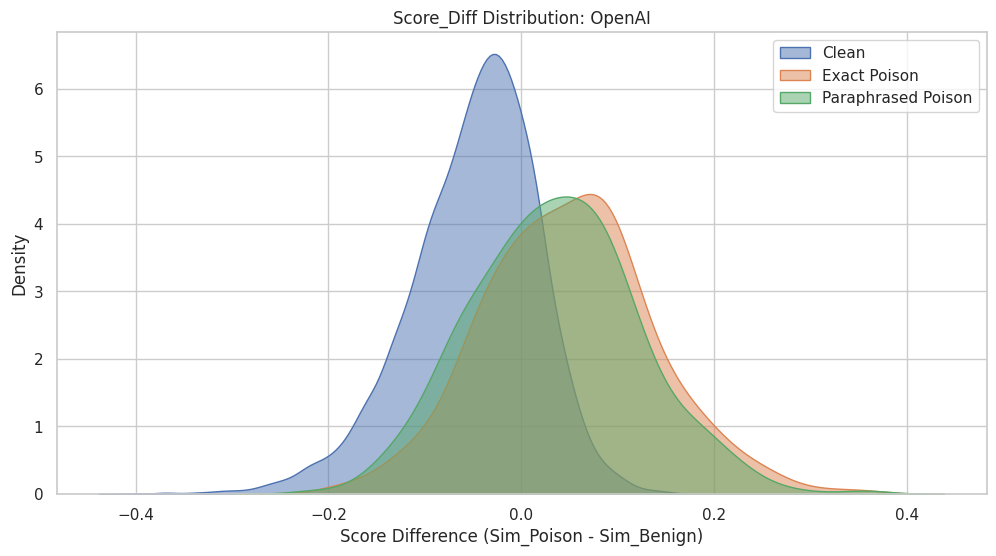

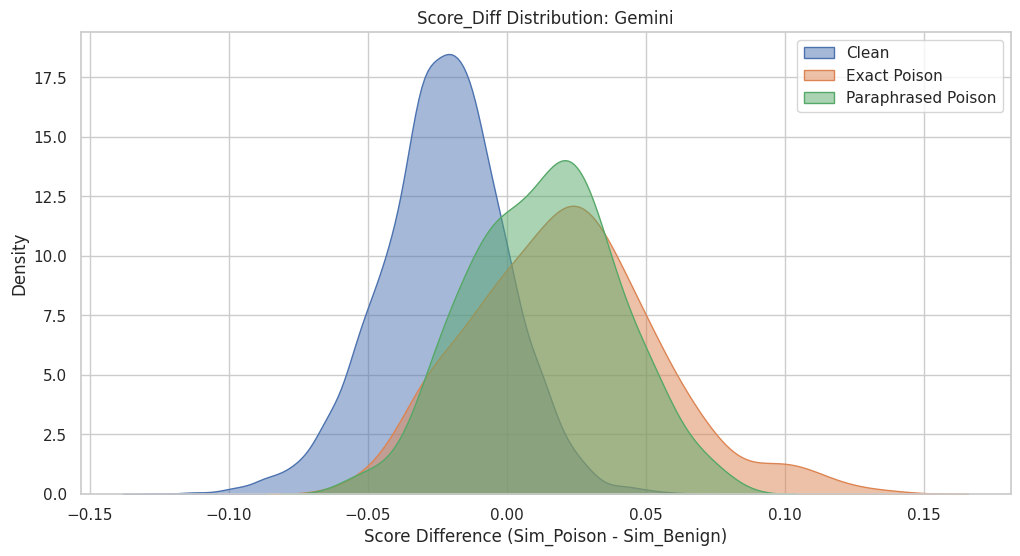

In [3]:
def plot_model_dist(model_name):
    model_df = df[df["Model"].str.contains(model_name, case=False)]

    plt.figure()
    for chunk_type in model_df["Type"].unique():
        subset = model_df[model_df["Type"] == chunk_type]
        sns.kdeplot(data=subset, x="Score_Diff", label=chunk_type, fill=True, alpha=0.5)

    plt.title(f"Score_Diff Distribution: {model_name}")
    plt.xlabel("Score Difference (Sim_Poison - Sim_Benign)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


plot_model_dist("OpenAI")
plot_model_dist("Gemini")

## 2. Statistical Separation Summary

In [4]:
summary = df.groupby(["Model", "Type"])["Score_Diff"].agg(["mean", "std", "median"]).round(4)
display(summary)

mean     std  median
Model           Type                                      
Gemini (wide)   Clean              -0.0230  0.0229 -0.0223
                Exact Poison        0.0211  0.0335  0.0207
                Paraphrased Poison  0.0134  0.0264  0.0139
OpenAI (narrow) Clean              -0.0496  0.0670 -0.0421
                Exact Poison        0.0494  0.0872  0.0491
                Paraphrased Poison  0.0349  0.0863  0.0352

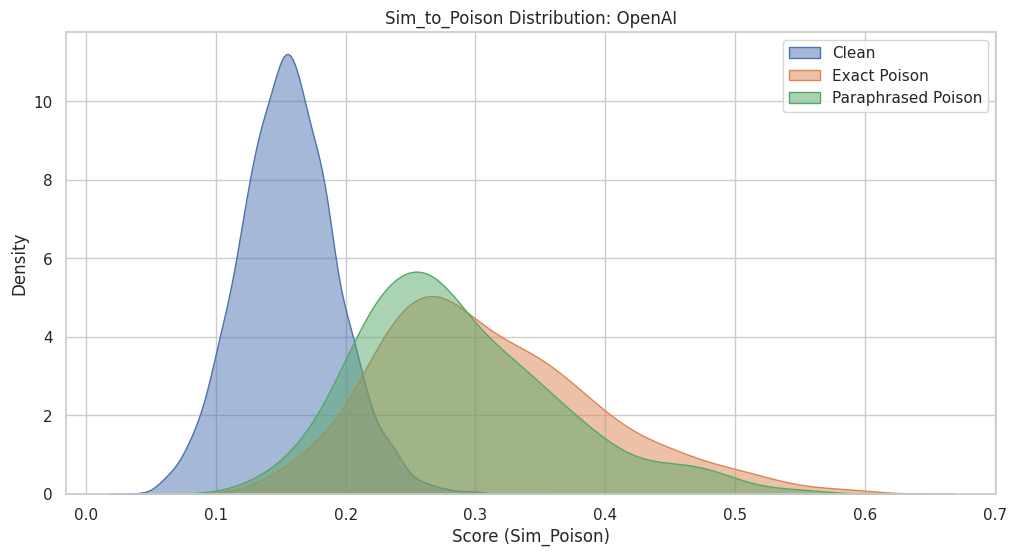

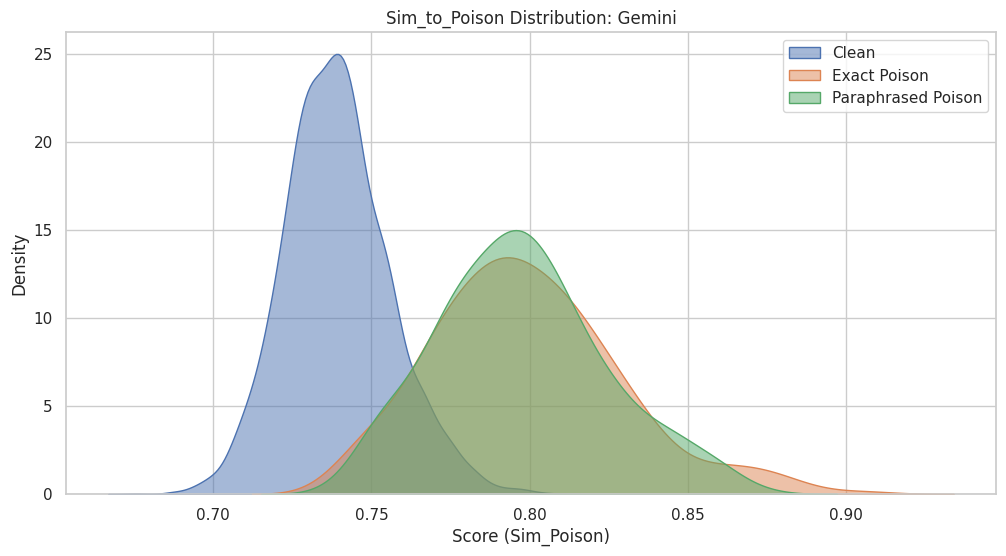

In [5]:
def plot_model_dist(model_name):
    model_df = df[df["Model"].str.contains(model_name, case=False)]

    plt.figure()
    for chunk_type in model_df["Type"].unique():
        subset = model_df[model_df["Type"] == chunk_type]
        sns.kdeplot(data=subset, x="Sim_to_Poison", label=chunk_type, fill=True, alpha=0.5)

    plt.title(f"Sim_to_Poison Distribution: {model_name}")
    plt.xlabel("Score (Sim_Poison)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


plot_model_dist("OpenAI")
plot_model_dist("Gemini")

## 3. Quantitative Separation: AUC-ROC and d-prime

To determine which model is objectively better at separating the classes, we use:
*   **AUC-ROC:** Area under the Receiver Operating Characteristic curve. 1.0 is perfect separation, 0.5 is random guessing.
*   **d-prime (Sensitivity Index):** The distance between the means of the Clean and Poisoned distributions, normalized by their standard deviation. Higher is better.

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve


def calculate_metrics(model_name):
    model_df = df[df["Model"].str.contains(model_name, case=False)].copy()

    # Create binary label: 1 for any Poison, 0 for Clean
    model_df["is_poison"] = model_df["Type"].apply(lambda x: 1 if "Poison" in x else 0)

    auc = roc_auc_score(model_df["is_poison"], model_df["Score_Diff"])

    # Calculate d-prime
    clean = model_df[model_df["is_poison"] == 0]["Score_Diff"]
    poison = model_df[model_df["is_poison"] == 1]["Score_Diff"]

    d_prime = (poison.mean() - clean.mean()) / np.sqrt(0.5 * (poison.var() + clean.var()))

    return {"Model": model_name, "AUC-ROC": auc, "d-prime": d_prime}


results = [calculate_metrics("OpenAI"), calculate_metrics("Gemini")]

metrics_df = pd.DataFrame(results)
display(metrics_df)

## 4. Visualizing the ROC Curve

In [ ]:
plt.figure(figsize=(8, 8))

for model_name in ["OpenAI", "Gemini"]:
    model_df = df[df["Model"].str.contains(model_name, case=False)].copy()
    model_df["is_poison"] = model_df["Type"].apply(lambda x: 1 if "Poison" in x else 0)

    fpr, tpr, _ = roc_curve(model_df["is_poison"], model_df["Score_Diff"])
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc_score(model_df['is_poison'], model_df['Score_Diff']):.3f})",
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Poison Detection Sensitivity")
plt.legend()
plt.show()

## 5. Statistical Significance: Bootstrap Test for AUC Difference

Is the difference between Gemini (0.857) and OpenAI (0.798) statistically significant? We use bootstrapping to calculate the 95% confidence interval for the difference in AUCs.

In [ ]:
from sklearn.utils import resample


def bootstrap_auc_diff(df, n_iterations=1000):
    diffs = []

    # We need to ensure we resample the SAME indices for both models
    # to account for the fact that they are tested on the same chunks.
    unique_ids = df["ID"].unique()

    for _i in range(n_iterations):
        # Resample IDs with replacement
        boot_ids = resample(unique_ids)
        boot_df = df[df["ID"].isin(boot_ids)]

        # Calculate AUC for both in this bootstrap sample
        oai = boot_df[boot_df["Model"].str.contains("OpenAI", case=False)]
        gem = boot_df[boot_df["Model"].str.contains("Gemini", case=False)]

        if len(oai["Type"].unique()) < 2 or len(gem["Type"].unique()) < 2:
            continue

        oai_auc = roc_auc_score(
            oai["Type"].apply(lambda x: 1 if "Poison" in x else 0), oai["Score_Diff"]
        )
        gem_auc = roc_auc_score(
            gem["Type"].apply(lambda x: 1 if "Poison" in x else 0), gem["Score_Diff"]
        )

        diffs.append(gem_auc - oai_auc)

    diffs = np.array(diffs)
    ci_low = np.percentile(diffs, 2.5)
    ci_high = np.percentile(diffs, 97.5)
    p_value = np.mean(diffs <= 0)

    return ci_low, ci_high, p_value, diffs


ci_low, ci_high, p_val, diff_dist = bootstrap_auc_diff(df)

print(f"Difference in AUC (Gemini - OpenAI): {0.8569 - 0.7982:.4f}")
print(f"95% Confidence Interval: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"P-value: {p_val:.4f}")

if ci_low > 0:
    print("\nVERDICT: The difference is STATISTICALLY SIGNIFICANT (Gemini is better).")
else:
    print("\nVERDICT: The difference is NOT statistically significant.")

plt.figure(figsize=(10, 5))
sns.histplot(diff_dist, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Bootstrap Distribution of AUC Difference (Gemini - OpenAI)")
plt.xlabel("$\\Delta$ AUC")
plt.show()